# **4. Mel Spectograms**

The function `parse_dataset_mel()` transforms raw audio files into perceptually meaningful time–frequency representations using a **Mel spectrogram**.

Instead of using a standard linear-frequency spectrogram, we apply a Mel filter bank on top of the Short-Time Fourier Transform (STFT). This maps frequencies to the **Mel scale**, which approximates how humans perceive sound.

This representation emphasizes lower frequencies (where most relevant acoustic information exists) and compresses higher frequencies.

We obtain:

* A 2D matrix where:

  * The **x-axis** represents time (short analysis windows)
  * The **y-axis** represents Mel frequency bands
  * Each cell represents the energy (power) of a Mel frequency at a specific time (expressed in decibels)



### LIBRARIES

In [1]:
print("Mel Spectogram :)")

Mel Spectogram :)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import os
import IPython.display as ipd
import librosa
import soundfile as sf
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import json
from datetime import datetime

### Data Paths

In [3]:
output_segmented_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats"
output_segmented_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs"

## **1. Data Preprocessing**

In [4]:
def parse_dataset_mel(dataset_paths):
    X = []
    y = []

    for index, dataset in enumerate(dataset_paths):
        print(f"[+] Parsing {dataset} data...")

        for fname in os.listdir(dataset):
            wav, sr = librosa.load(os.path.join(dataset, fname), sr=None)

            mel_spec = librosa.feature.melspectrogram(
                y=wav,
                sr=sr,
                n_fft=1024,
                hop_length=512,
                n_mels=128 
            )

            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            X.append(mel_spec_db)
            y.append(index)

    return X, y



dataset_paths = [output_segmented_cats_path, output_segmented_dogs_path]
X, y = parse_dataset_mel(dataset_paths)

[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats data...


c:\Users\Ale\Documents\Lab01\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs data...


In [5]:
print(y)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [6]:
print("The length of the data set is: ", len(X))

The length of the data set is:  580


#### We divide the dataset into training and testing.

In [7]:
print(np.array(X).shape)


(580, 128, 130)


In [8]:
X_array = np.array(X)

X_prep = X_array.reshape(X_array.shape[0], -1)
X_prep = X_prep.astype('float32')

y_prep = np.array(y).astype('float32')

print(X_prep.shape)

(580, 16640)


In [9]:
y_prep = np.array(y).astype('float32')

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_prep, y_prep, test_size=0.15, random_state=42)

In [11]:
print("Length of training subset: ", len(X_train))
print("Lenght of testing subset: ", len(X_test))

Length of training subset:  493
Lenght of testing subset:  87


Text(0.5, 1.0, 'Distribution of classes in the training set')

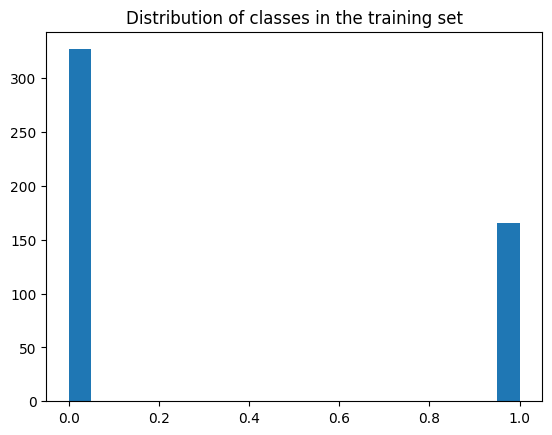

In [12]:
plt.hist(y_train, bins=20)
plt.title("Distribution of classes in the training set")

### **1. Model Construction**

In [13]:
network = models.Sequential()

network.add(layers.Dense(50, activation='relu', input_shape=(X_train.shape[1],)))
network.add(layers.Dense(100, activation='relu'))
network.add(layers.Dense(1, activation='sigmoid'))

network.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', 'Precision'])


history = network.fit(X_train, 
                      y_train,
                      batch_size=32,
                      epochs=15, 
                      validation_data=(X_test, y_test))



Epoch 1/15


16/16 [==============================] - 1s 22ms/step - loss: 181.4557 - accuracy: 0.4990 - precision: 0.3005 - val_loss: 23.2077 - val_accuracy: 0.3218 - val_precision: 0.3218
Epoch 2/15
16/16 [==============================] - 0s 8ms/step - loss: 56.3735 - accuracy: 0.5680 - precision: 0.3423 - val_loss: 31.9001 - val_accuracy: 0.6782 - val_precision: 0.0000e+00
Epoch 3/15
16/16 [==============================] - 0s 7ms/step - loss: 14.8051 - accuracy: 0.6227 - precision: 0.4419 - val_loss: 3.6044 - val_accuracy: 0.7356 - val_precision: 0.5714
Epoch 4/15
16/16 [==============================] - 0s 7ms/step - loss: 2.7912 - accuracy: 0.8276 - precision: 0.7485 - val_loss: 2.9931 - val_accuracy: 0.7471 - val_precision: 0.5833
Epoch 5/15
16/16 [==============================] - 0s 8ms/step - loss: 2.0681 - accuracy: 0.8621 - precision: 0.7917 - val_loss: 3.7900 - val_accuracy: 0.8161 - val_precision: 1.0000
Epoch 6/15
16/16 [==============================] - 0s 8ms/step -

In [14]:
y_pred_probs = network.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

3/3 [==============================] - 0s 3ms/step


In [15]:
y_test = np.array(y_test).flatten()

### **RESULTS**

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7701149425287356
Precision: 0.6
Recall: 0.8571428571428571
F1 Score: 0.7058823529411765
AUC: 0.85260296

Confusion Matrix:
[[43 16]
 [ 4 24]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.73      0.81        59
         1.0       0.60      0.86      0.71        28

    accuracy                           0.77        87
   macro avg       0.76      0.79      0.76        87
weighted avg       0.81      0.77      0.78        87



In [17]:
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy()

display(HTML(f"""
<div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
</div>
"""))


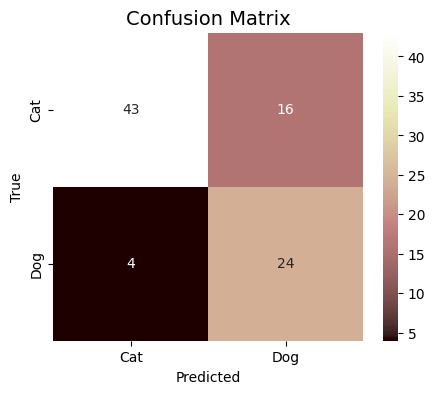

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [19]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient(cmap="RdPu")

,precision,recall,f1-score,support
0.0,0.914894,0.728814,0.811321,59.000000
1.0,0.600000,0.857143,0.705882,28.000000
accuracy,0.770115,0.770115,0.770115,0.770115
macro avg,0.757447,0.792978,0.758602,87.000000
weighted avg,0.813549,0.770115,0.777387,87.000000


Save the metrics

In [20]:

model_name = "4. MLP"
representation = "Mel Spectogram"
save_dir_path = "model_metrics"

metrics_dict = {"model": model_name,
        "representation": representation,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

if not os.path.exists(save_dir_path):
    os.makedirs(save_dir_path, exist_ok=True)

file_path = os.path.join(save_dir_path, f"{model_name}_{representation}.json")

with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
print(f"Metrics saved to: {file_path}")

Metrics saved to: model_metrics\4. MLP_Mel Spectogram.json
